In [ ]:
pip install shap

In [ ]:
pip install openpyxl


In [ ]:
import shap
from google.colab import files
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
# Upload your CSV from local
uploaded = files.upload()

Saving question.xlsx to question.xlsx
Saving ResultsForSurvey-525 - 01-12-2026 08_38_35.xlsx to ResultsForSurvey-525 - 01-12-2026 08_38_35.xlsx


In [ ]:
# Load it into a DataFrame
df = pd.read_excel("ResultsForSurvey-525 - 01-12-2026 08_38_35.xlsx")  # replace with actual filename

In [ ]:
# Load it into a DataFrame
df_pitanja = pd.read_excel("question.xlsx")  # replace with actual filename

In [ ]:
df = df.drop(columns=[
    'ResultId', 'Project', 'Survey', 'Language', 'UserGroup',
    'Code', 'AccessId', 'Access', 'Segments', 'CurrentPage','Progress', 'StartTime', 'EndTime','Test'
])


In [ ]:
ordinal_vars = []

for qid, qtype, options in zip(df_pitanja["QuestionID"], df_pitanja["Type"], df_pitanja["Options"]):
    if qtype == "Scale" and pd.notnull(options):
        choices = [opt.strip() for opt in str(options).split(';') if '=' in opt]
        if len(choices) > 3:   # more than 3 options
            ordinal_vars.append(str(qid))

# same cleanup you used (remove .0)
ordinal_vars = [str(int(float(col))) if str(col).endswith('.0') else str(col) for col in ordinal_vars]

In [ ]:
select_one = []
for qid, qtype in zip(df_pitanja["QuestionID"], df_pitanja["Type"]):
    if qtype == "SelectOne":
        select_one.append(qid)
select_one = [str(int(float(col))) if str(col).endswith('.0') else str(col) for col in select_one]

In [ ]:
multi_nominal_cols = []
for qid, qtype in zip(df_pitanja["QuestionID"], df_pitanja["Type"]):
    if qtype == "SelectMultiple":
        multi_nominal_cols.append(qid)
multi_nominal_cols = [str(int(float(col))) if str(col).endswith('.0') else str(col) for col in multi_nominal_cols]

In [ ]:
binary = []

for qid, qtype, options in zip(df_pitanja["QuestionID"], df_pitanja["Type"], df_pitanja["Options"]):
    if qtype == "Scale" and pd.notnull(options):
        choices = [opt.strip() for opt in str(options).split(';') if '=' in opt]
        if len(choices) <= 3:   # <= 3 options
            binary.append(str(qid))

binary = [str(int(float(col))) if str(col).endswith('.0') else str(col) for col in binary]

In [ ]:
# See missing values per column
df_mising=df.isnull().sum().sort_values(ascending=False)

In [ ]:
df_mising

,0
568.3,0
285,0
280,0
313,0
282.9,0
...,...
694.1_missing_all,0
694.1_2.0,0
694.1_3.0,0
694.1_4.0,0


In [ ]:
za_drop = []

for index, value in df_mising.items():
    if value > 30:
        za_drop.append(index)

In [ ]:
za_drop = [str(int(float(col))) if str(col).endswith('.0') else str(col) for col in za_drop]

In [ ]:
za_drop2 = []

for qid, qtype in zip(df_pitanja["QuestionID"], df_pitanja["Type"]):
    if qtype == "Text":
        za_drop2.append(str(qid))  # convert to string here


In [ ]:
za_drop2_cleaned = [str(int(float(col))) if str(col).endswith('.0') else str(col) for col in za_drop2]

In [ ]:
# 🔹 Step 2: Drop rows where 379.1 is missing
df = df[df['379'].notna()]

In [ ]:
df = df.drop(columns=za_drop)

In [ ]:
df = df.drop(columns=za_drop2_cleaned, errors='ignore')


In [ ]:
# Step 2: Filter out columns that don’t exist in the DataFrame
ordinal_vars = [col for col in ordinal_vars if col in df.columns]

# Step 3: Convert only valid ones
for col in ordinal_vars:
    df[col] = df[col].astype('Int64')


In [ ]:
for col in multi_nominal_cols:
    if col in df.columns:
        # Step 1: Clean missing and convert to string
        df[col] = df[col].fillna('').astype(str)

        # Step 2: One-hot encode selections
        dummies = df[col].str.get_dummies(sep=';')
        dummies.columns = [f"{col}_{c.strip()}" for c in dummies.columns]

        # Step 3: Create missing-all flag BEFORE dropping or joining
        df[f'{col}_missing_all'] = dummies.sum(axis=1).eq(0).astype(int)

        # Step 4: Replace original with dummies
        df = df.drop(columns=[col])
        df = pd.concat([df, dummies], axis=1)


In [ ]:
for col in select_one:
    if col in df.columns:
        # Step 1: Clean missing and convert to string
        df[col] = df[col].fillna('').astype(str)

        # Step 2: One-hot encode selections
        dummies = df[col].str.get_dummies(sep=',')
        dummies.columns = [f"{col}_{c.strip()}" for c in dummies.columns]

        # Step 3: Create missing-all flag BEFORE dropping or joining
        df[f'{col}_missing_all'] = dummies.sum(axis=1).eq(0).astype(int)

        # Step 4: Replace original with dummies
        df = df.drop(columns=[col])
        df = pd.concat([df, dummies], axis=1)


In [ ]:
for col in binary:
    if col in df.columns:
        # Step 1: Clean missing and convert to string
        df[col] = df[col].fillna('').astype(str)

        # Step 2: One-hot encode selections
        dummies = df[col].str.get_dummies(sep=',')
        dummies.columns = [f"{col}_{c.strip()}" for c in dummies.columns]

        # Step 3: Create missing-all flag BEFORE dropping or joining
        df[f'{col}_missing_all'] = dummies.sum(axis=1).eq(0).astype(int)

        # Step 4: Replace original with dummies
        df = df.drop(columns=[col])
        df = pd.concat([df, dummies], axis=1)

In [ ]:
import numpy as np

# Compute correlation matrix
corr = df.corr()

# Extract upper triangle (to avoid duplicates)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Unstack into long form
strong_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={0: "Correlation", "level_0": "Var1", "level_1": "Var2"})
)

# Filter for absolute correlation above threshold
threshold = 0.8
strong_corr = strong_corr[strong_corr["Correlation"].abs() > threshold]

print(strong_corr)

          Var1     Var2  Correlation
2856     198.1      198     1.000000
5583       370      156     0.823759
8903       159      379     0.803108
10665  440_1.0  440_2.0    -0.869227


In [ ]:
cols_to_drop = ['198.1', '440_2.0']
df = df.drop(columns=cols_to_drop)


In [ ]:
def nps_reverse(score):
    if score in [1, 2]:
        return "Promoter"
    elif score in [3, 4]:
        return "Passive"
    else:
        return "Detractor"

df["nps_category"] = df["379"].apply(nps_reverse)


In [ ]:
cols_to_drop = ["379"]
df = df.drop(columns=cols_to_drop)

In [ ]:
# ─────────── STEP 1: Identify target and excluded columns ───────────
target_col = 'nps_category'
always_normal_direction = ['']  # Add known positive-direction columns if needed
excluded_columns = [target_col]    # add any others you don’t want to process

# ─────────── STEP 2: Determine which columns to standardize ───────────
columns_to_process = [
    c for c in df.columns
    if c not in excluded_columns and df[c].nunique() > 2
]

# ─────────── STEP 3: Flip scale direction if needed ───────────
df_proc = df.copy()
cols_to_flip = []

for c in columns_to_process:
    if c in always_normal_direction:
        continue
    try:
        df_proc[c] = pd.to_numeric(df_proc[c], errors='coerce')
        col_min, col_max = df_proc[c].min(), df_proc[c].max()
        df_proc[c] = col_max + col_min - df_proc[c]
        cols_to_flip.append(c)
    except:
        print(f"⚠️ Skipping flip: {c} contains non-numeric values")

# ─────────── STEP 4: Ensure numeric columns ───────────
for col in columns_to_process:
    df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')

# ─────────── STEP 5: Prepare model inputs ───────────
X = df_proc.drop(columns=[target_col])
Y = df_proc[target_col]

# Split FIRST ✅ (so imputer/scaler learn only from training data)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

# Ensure we only process columns present in X_train
columns_to_process = [c for c in columns_to_process if c in X_train.columns]

# ─────────── STEP 6: Impute missing values on TRAIN only, then apply to TEST ───────────
imputer = SimpleImputer(strategy="median")
X_train[columns_to_process] = imputer.fit_transform(X_train[columns_to_process])
X_test[columns_to_process] = imputer.transform(X_test[columns_to_process])

In [ ]:
# ───────────────────────────────────────────────────────────────
# STEP 1: Import libraries

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import shap
import numpy as np

# STEP 2: Define the model

rf = RandomForestClassifier(random_state=42)

# STEP 3: Define the hyperparameter grid
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# STEP 4: Grid search with cross-validation
rf_cv = GridSearchCV(
    rf,
    param_grid=params,
    cv=10,
    scoring='accuracy',   # you can change to 'f1_macro' for imbalanced classes
    n_jobs=-1
)

rf_cv.fit(X_train, Y_train)

print("✅ Best parameters:", rf_cv.best_params_)
print("✅ Best cross-val Accuracy:", rf_cv.best_score_)

# ───────────────────────────────────────────────────────────────
# STEP 5: Use the best model
# ───────────────────────────────────────────────────────────────
best_rf = rf_cv.best_estimator_


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


✅ Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best cross-val Accuracy: 0.725


In [ ]:
# ───────────────────────────────────────────────────────────────
# STEP 1: Import libraries
# ───────────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import shap
import numpy as np

# ───────────────────────────────────────────────────────────────
# STEP 2: Define the model
# ───────────────────────────────────────────────────────────────
gb = GradientBoostingClassifier(random_state=42)

# ───────────────────────────────────────────────────────────────
# STEP 3: Define the hyperparameter grid
# ───────────────────────────────────────────────────────────────
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

# ───────────────────────────────────────────────────────────────
# STEP 4: Grid search with cross-validation
# ───────────────────────────────────────────────────────────────
gb_cv = GridSearchCV(
    gb,
    param_grid=params,
    cv=10,
    scoring='accuracy',   # or 'f1_macro' for imbalanced 3-class data
    n_jobs=-1,
    verbose=1
)

gb_cv.fit(X_train, Y_train)

print("✅ Best parameters:", gb_cv.best_params_)
print("✅ Best cross-val Accuracy:", gb_cv.best_score_)

# ───────────────────────────────────────────────────────────────
# STEP 5: Use the best model
# ───────────────────────────────────────────────────────────────
best_gb = gb_cv.best_estimator_


Fitting 10 folds for each of 162 candidates, totalling 1620 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


✅ Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.8}
✅ Best cross-val Accuracy: 0.6666666666666666


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
import pandas as pd

# --- Evaluation helper for classification ---
def evaluate_model(model, X_test, Y_test, name):
    preds = model.predict(X_test)

    # Handle binary vs multiclass automatically
    average_type = 'binary'
    if len(np.unique(Y_test)) > 2:
        average_type = 'macro'  # or 'weighted' if class imbalance

    acc = accuracy_score(Y_test, preds)
    prec = precision_score(Y_test, preds, average=average_type)
    rec = recall_score(Y_test, preds, average=average_type)
    f1 = f1_score(Y_test, preds, average=average_type)

    # Probabilistic metrics (works only for binary/multiclass with predict_proba)
    try:
        probs = model.predict_proba(X_test)
        if probs.shape[1] == 2:
            auc = roc_auc_score(Y_test, probs[:, 1])
        else:
            auc = roc_auc_score(Y_test, probs, multi_class='ovr')
    except Exception:
        auc = np.nan  # fallback if model doesn’t support predict_proba

    return pd.Series({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC AUC': auc
    })

# --- Evaluate your models ---
results = pd.concat([
    evaluate_model(best_rf, X_test, Y_test, 'RandomForest (full)'),
    evaluate_model(best_gb, X_test, Y_test, 'GradientBoost (full)')

], axis=1).T

# --- Sort and display neatly ---
results = results.sort_values(by='Accuracy', ascending=False)
print("\n📊 Classification Results:")
print(results)



📊 Classification Results:
                  Model  Accuracy Precision    Recall  F1-score   ROC AUC
1  GradientBoost (full)  0.777778  0.866667  0.777778      0.75   0.87037
0   RandomForest (full)  0.666667       0.5  0.666667  0.555556  0.833333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(best_rf.classes_)


['Detractor' 'Passive' 'Promoter']


In [ ]:
explainer = shap.TreeExplainer(best_rf)   # ← this line defines 'explainer'

In [ ]:
shap_values = explainer.shap_values(X_train)


In [ ]:
class_idx = 0  # <- change to the class you want to visualize
sv_class = shap_values[:, :, class_idx]   # (n_samples, n_features)


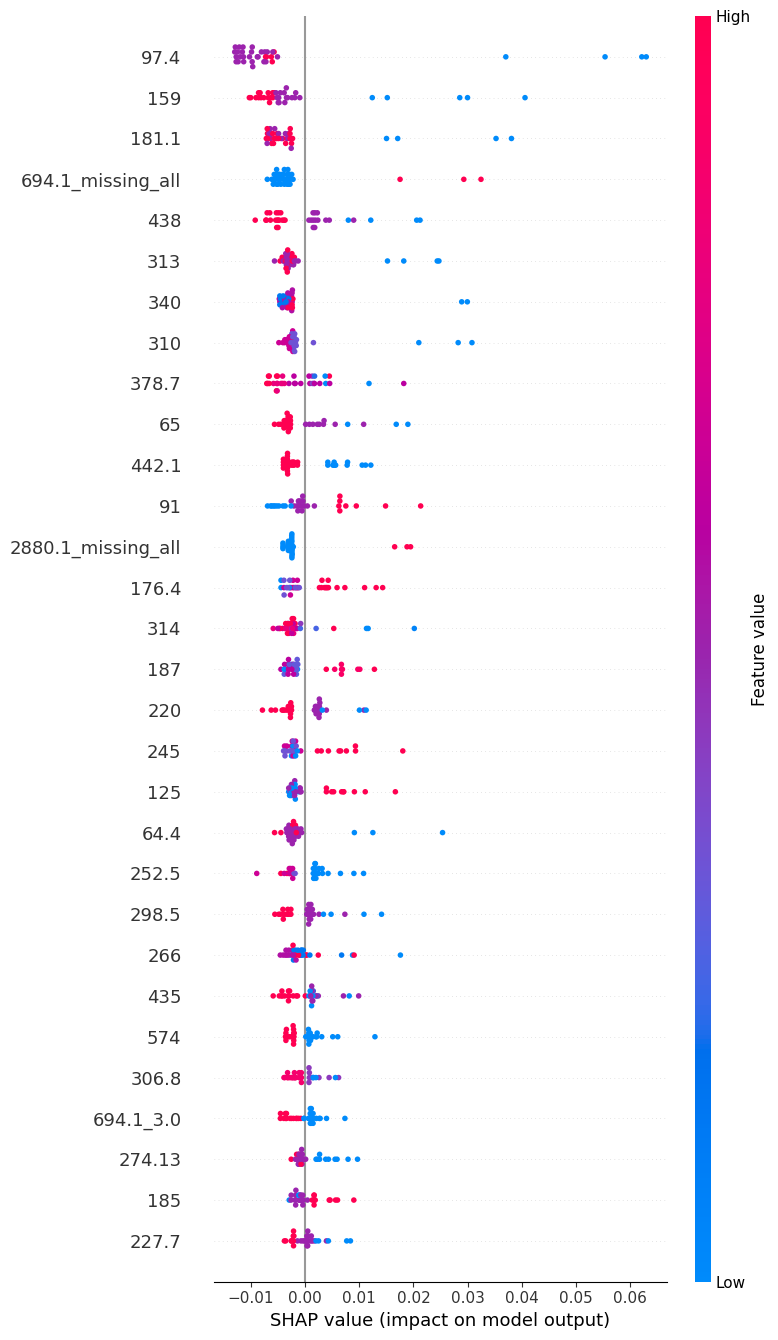

In [ ]:
import shap
shap.summary_plot(sv_class, X_train, plot_type="dot", max_display=30)


In [ ]:
# Mean absolute SHAP over samples AND classes
global_mean_abs = np.abs(shap_values).mean(axis=(0, 2))  # shape: (n_features,)

global_top10 = (pd.DataFrame({
    "Feature": X_train.columns,
    "Mean |SHAP| (global)": global_mean_abs
})
.sort_values("Mean |SHAP| (global)", ascending=False)
.head(15))
print(global_top10)


    Feature  Mean |SHAP| (global)
87    378.7              0.031867
85      159              0.020584
86      314              0.017283
117     220              0.016053
26    298.5              0.014296
32      438              0.013411
104    97.4              0.010857
120   252.5              0.008981
8     275.9              0.008958
84       65              0.008607
83       58              0.008308
59      266              0.007595
17    148.7              0.007399
30      435              0.007388
73      574              0.006908


In [ ]:
df_pitanja

,QuestionID,Type,Text,Options
0,568.3,Scale,In unserer Bank erkennen wir Automatisierungsp...,1=trifft vollständig zu; 2=trifft weitgehend z...
1,285.0,Scale,In unserer Bank nutzen wir bewusst Spielräume ...,1=trifft vollständig zu; 2=trifft weitgehend z...
2,280.0,Scale,"Unsere Bank hilft ihren Kund:innen, das Leben ...",1=trifft vollständig zu; 2=trifft weitgehend z...
3,313.0,Scale,Unsere Bank bietet ihren Kund:innen einen groß...,1=trifft vollständig zu; 2=trifft weitgehend z...
4,282.9,Scale,Unsere Bank bringt neue Technologien sehr rasc...,1=trifft vollständig zu; 2=trifft weitgehend z...
...,...,...,...,...
134,2145.0,Text,In welchen sonstigen Bereichen sehen sie Chanc...,NaN
135,416.0,Scale,Ihr Geschlecht?,1=weiblich; 2=männlich; 3=divers;
136,694.1,SelectOne,Ihr Geburtsjahr?,2=1945 bis 1964; 3=1965 bis 1980; 4=1981 bis 1...
137,252.5,Scale,Wie lange sind Sie bereits in dieser Bank tätig?,1=weniger als 1 Jahr; 2=1 - 3 Jahre; 3=4 - 7 J...


In [ ]:
global_top10

,Feature,Mean |SHAP| (global)
87,378.7,0.031867
85,159,0.020584
86,314,0.017283
117,220,0.016053
26,298.5,0.014296
32,438,0.013411
104,97.4,0.010857
120,252.5,0.008981
8,275.9,0.008958
84,65,0.008607


In [ ]:
global_top10['Feature'] = pd.to_numeric(global_top10['Feature'], errors='coerce')

In [ ]:
global_top10 = global_top10.merge(
    df_pitanja[['QuestionID', 'Text']],
    left_on='Feature',
    right_on='QuestionID',
    how='left'
)


In [ ]:
global_top10

,Feature,Mean |SHAP| (global),QuestionID,Text
0,378.7,0.031867,378.7,"Ich würde einem/r guten Freund:in raten, in me..."
1,159.0,0.020584,159.0,Ich sehe für unsere Bank eine sehr erfolgreich...
2,314.0,0.017283,314.0,"Ich würde einem/r guten Freund:in raten, in me..."
3,220.0,0.016053,220.0,"gehen wir offen, vertrauensvoll und wertschätz..."
4,298.5,0.014296,298.5,werden den Mitarbeiter:innen gute Möglichkeite...
5,438.0,0.013411,438.0,"Tonalität in der Kommunikation (Respekt, Freun..."
6,97.4,0.010857,97.4,"Alles in allem, wie zufrieden sind Sie mit Ihr..."
7,252.5,0.008981,252.5,Wie lange sind Sie bereits in dieser Bank tätig?
8,275.9,0.008958,275.9,Ich kenne die für mich relevanten strategische...
9,65.0,0.008607,65.0,"Ich bin stolz darauf, für diese Bank zu arbeiten."


In [ ]:
global_top10.to_excel("xy.xlsx", index=False)


In [ ]:
from google.colab import files
files.download("xy.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>